# Capítulo 10 — Forças e Ventos: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | círculos inerciais e cicloides | `scipy.solve_ivp` |
| 2 | geostrófico × gradiente numa baixa sintética (HS) | NumPy |
| 3 | espiral de Ekman: analítica × numérica | NumPy |
| 4 | atrito → convergência → mapa de $w$: onde o ar sobe | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap10_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Omega = 7.292e-5
f_lat = lambda phi_g: 2*Omega*np.sin(np.deg2rad(phi_g))
rho = 1.2

## Caso 1 — Círculos inerciais: Coriolis dançando sozinha

$$\frac{du}{dt} = f\,v,\qquad \frac{dv}{dt} = -f\,u$$

Sem pressão nem atrito, o ar gira em círculos de raio $V/|f|$ e período $2\pi/|f|$ — anti-horário no HS.

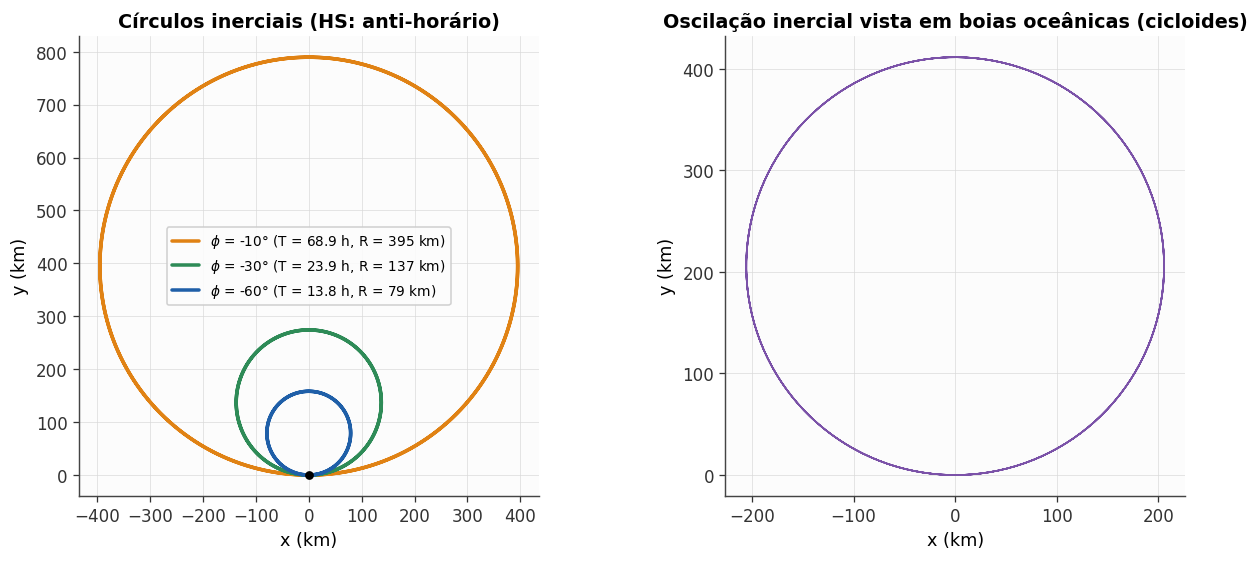

Boias de deriva no oceano mostram exatamente estes loops após tempestades.


In [2]:
def inercial(t, y, f):
    x, yy, u, v = y
    return [u, v, f*v, -f*u]

V0 = 10.0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))
for phi, cor in [(-10, CORES['laranja']), (-30, CORES['verde']),
                  (-60, CORES['azul'])]:
    f = f_lat(phi)
    T_in = 2*np.pi/abs(f)
    sol = solve_ivp(inercial, [0, 2*T_in], [0, 0, V0, 0], args=(f,),
                    max_step=600, rtol=1e-9)
    ax1.plot(sol.y[0]/1e3, sol.y[1]/1e3, color=cor,
             label=f'$\\phi$ = {phi}° (T = {T_in/3600:.1f} h, '
                   f'R = {V0/abs(f)/1e3:.0f} km)')
ax1.scatter([0], [0], color='k', zorder=5, s=20)
ax1.set(xlabel='x (km)', ylabel='y (km)', title='Círculos inerciais (HS: anti-horário)')
ax1.legend(fontsize=8.5); ax1.set_aspect('equal')

# cicloide: círculo inercial + vento médio de 5 m/s
f = f_lat(-30)
sol = solve_ivp(inercial, [0, 4*2*np.pi/abs(f)], [0, 0, V0 + 5, 0], args=(f,),
                max_step=600, rtol=1e-9)
ax2.plot((sol.y[0] + 0)/1e3, sol.y[1]/1e3, color=CORES['roxo'], lw=1)
# na prática o 'vento médio' desloca o centro-guia; aqui a própria EDO gera a cicloide
ax2.set(xlabel='x (km)', ylabel='y (km)',
        title='Oscilação inercial vista em boias oceânicas (cicloides)')
ax2.set_aspect('equal')
fig.tight_layout(); plt.show()
print('Boias de deriva no oceano mostram exatamente estes loops após tempestades.')

## Caso 2 — Geostrófico × gradiente numa baixa do HS

Baixa sintética gaussiana em $30°$S. O vento gradiente resolve
$$\frac{V^2}{R} + |f|V - \frac{1}{\rho}\left|\frac{\partial P}{\partial r}\right| = 0\quad\text{(ciclone)}$$

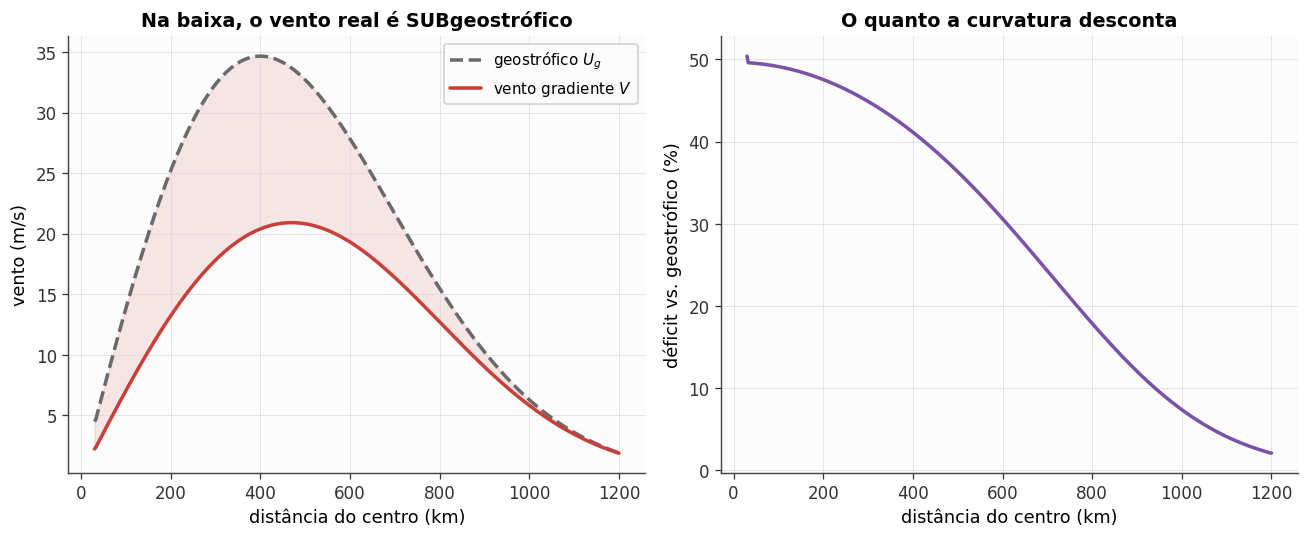

vento máximo: 20.9 m/s a 470 km (geostrófico ali: 33.7 m/s → déficit de 38%)


In [3]:
f = abs(f_lat(-30))
r = np.linspace(30e3, 1200e3, 400)
dP = 20e2                              # 20 hPa de déficit
L = 400e3
P_r = 101300 - dP*np.exp(-(r/L)**2/2)
PGF = np.gradient(P_r, r)/rho          # |∂P/∂r|/ρ (>0 para fora da baixa? sinal ok como módulo)

Ug = PGF/f
Vgrad = (-f*r + np.sqrt((f*r)**2 + 4*r*PGF))/2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax1.plot(r/1e3, Ug, color=CORES['cinza'], ls='--', label='geostrófico $U_g$')
ax1.plot(r/1e3, Vgrad, color=CORES['vermelho'], label='vento gradiente $V$')
ax1.fill_between(r/1e3, Vgrad, Ug, color=CORES['vermelho'], alpha=0.12)
ax1.set(xlabel='distância do centro (km)', ylabel='vento (m/s)',
        title='Na baixa, o vento real é SUBgeostrófico')
ax1.legend()
ax2.plot(r/1e3, 100*(1 - Vgrad/np.maximum(Ug, 1e-9)), color=CORES['roxo'])
ax2.set(xlabel='distância do centro (km)', ylabel='déficit vs. geostrófico (%)',
        title='O quanto a curvatura desconta')
fig.tight_layout(); plt.show()
i_max = np.argmax(Vgrad)
print(f'vento máximo: {Vgrad[i_max]:.1f} m/s a {r[i_max]/1e3:.0f} km '
      f'(geostrófico ali: {Ug[i_max]:.1f} m/s → déficit de '
      f'{100*(1-Vgrad[i_max]/Ug[i_max]):.0f}%)')

## Caso 3 — A espiral de Ekman

$$K U'' = -f(V),\qquad K V'' = f(U - U_g),\qquad \delta = \sqrt{2K/|f|}$$

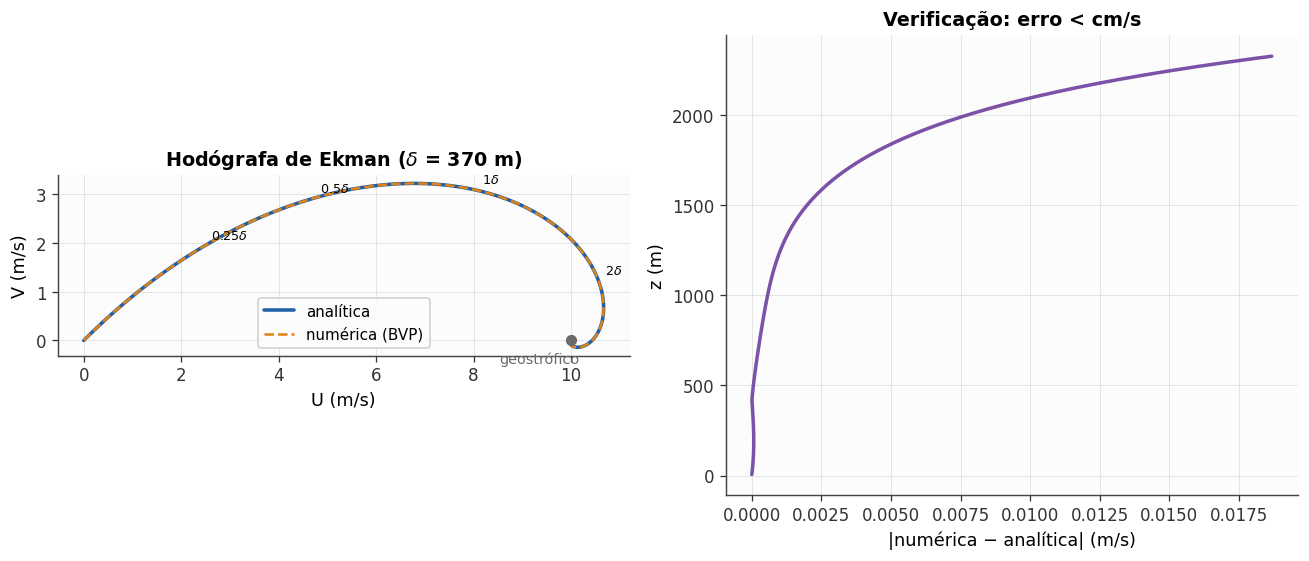

camada de Ekman: topo em ~π·δ = 1163 m; vento a 0,25δ cruza as isóbaras em 38°


In [4]:
Ug0, K = 10.0, 5.0
delta = np.sqrt(2*K/f)
z = np.linspace(0, 4*np.pi*delta/2, 400)

U_an = Ug0*(1 - np.exp(-z/delta)*np.cos(z/delta))
V_an = Ug0*np.exp(-z/delta)*np.sin(z/delta)

# numérica: BVP por relaxação (diferenças finitas, complex trick W = U + iV)
n = 400
zg = np.linspace(0, z[-1], n)
dz = zg[1] - zg[0]
# (K d²/dz² - i f) (W - Ug) = 0 → solve linear system
A = np.zeros((n, n), complex)
b = np.zeros(n, complex)
for i in range(1, n-1):
    A[i, i-1] = K/dz**2
    A[i, i]   = -2*K/dz**2 - 1j*f
    A[i, i+1] = K/dz**2
    b[i] = -1j*f*Ug0
A[0, 0] = 1.0; b[0] = 0.0                 # não-deslizamento no chão
A[-1, -1] = 1.0; b[-1] = Ug0              # geostrófico no topo
W = np.linalg.solve(A, b)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))
ax1.plot(U_an, V_an, color=CORES['azul'], lw=2.2, label='analítica')
ax1.plot(W.real, W.imag, '--', color=CORES['laranja'], lw=1.6,
         label='numérica (BVP)')
for zf in [0.25, 0.5, 1.0, 2.0]:
    i = np.argmin(np.abs(z - zf*delta))
    ax1.annotate(f'{zf:g}$\\delta$', (U_an[i], V_an[i]), fontsize=8,
                 xytext=(4, 4), textcoords='offset points')
ax1.scatter([Ug0], [0], color=CORES['cinza'], zorder=5)
ax1.annotate('geostrófico', (Ug0, 0), xytext=(-45, -14),
             textcoords='offset points', fontsize=9, color=CORES['cinza'])
ax1.set(xlabel='U (m/s)', ylabel='V (m/s)',
        title=f'Hodógrafa de Ekman ($\\delta$ = {delta:.0f} m)')
ax1.legend(); ax1.set_aspect('equal')
ax2.plot(np.abs(W - (U_an + 1j*V_an))[1:], zg[1:], color=CORES['roxo'])
ax2.set(xlabel='|numérica − analítica| (m/s)', ylabel='z (m)',
        title='Verificação: erro < cm/s')
fig.tight_layout(); plt.show()
print(f'camada de Ekman: topo em ~π·δ = {np.pi*delta:.0f} m; '
      f'vento a 0,25δ cruza as isóbaras em '
      f'{np.rad2deg(np.arctan2(V_an[np.argmin(abs(z-0.25*delta))], U_an[np.argmin(abs(z-0.25*delta))])):.0f}°')

## Caso 4 — Atrito → convergência → o mapa de onde chove

Vento geostrófico da baixa, girado 20° em direção à baixa pressão (atrito). A divergência desse campo dá $w = -h\,\nabla\cdot\vec U$ no topo da camada limite: o mapa da subida É o mapa das nuvens.

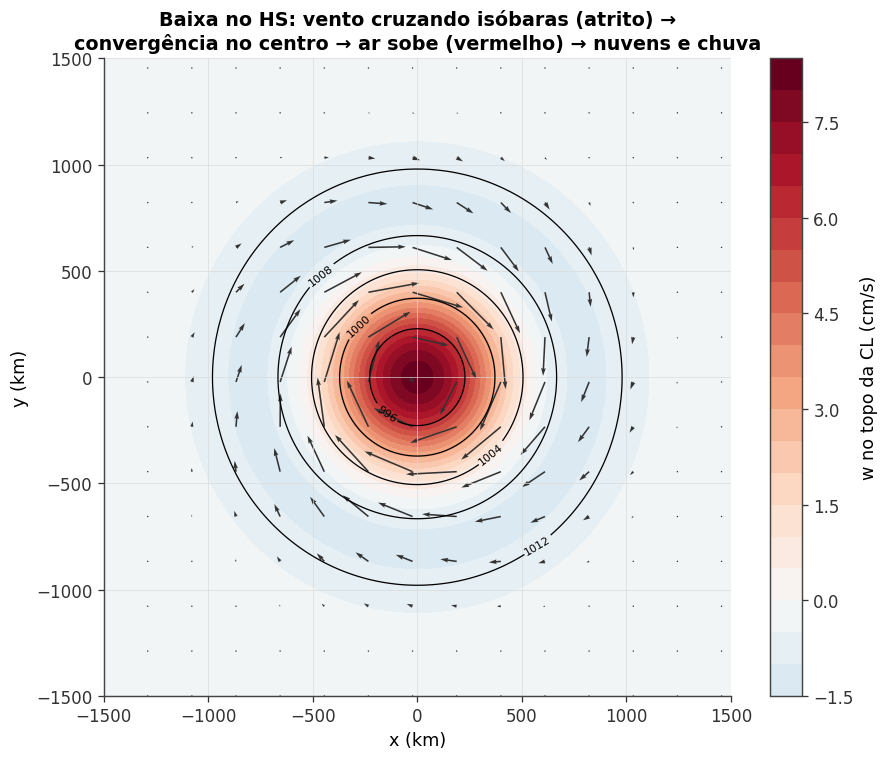

w máximo no centro: 8.3 cm/s — invisível a olho, suficiente para saturar o ar em poucas horas (Cap. 4).


In [5]:
x = np.linspace(-1500e3, 1500e3, 200)
X, Y = np.meshgrid(x, x)
R2 = X**2 + Y**2
P = 101300 - 20e2*np.exp(-R2/(2*(400e3)**2))

dPdx = np.gradient(P, x, axis=1)
dPdy = np.gradient(P, x, axis=0)
# geostrófico no HS (f<0): Ug = -(1/ρf) ∂P/∂y ... com f<0 os sinais giram o vento no sentido horário em torno da baixa
f_s = f_lat(-30)                      # negativo!
Ugx = -dPdy/(rho*f_s)
Ugy =  dPdx/(rho*f_s)

# atrito: gira 20° em direção à baixa e reduz 15%
ang = np.deg2rad(20)*np.sign(f_s)     # HS: girar horário → para o centro
Ux = 0.85*(Ugx*np.cos(ang) - Ugy*np.sin(ang))
Uy = 0.85*(Ugx*np.sin(ang) + Ugy*np.cos(ang))

div = np.gradient(Ux, x, axis=1) + np.gradient(Uy, x, axis=0)
w_topo = -1000.0*div*100              # cm/s (camada de 1 km)

fig, ax = plt.subplots(figsize=(8.8, 7.2))
cf = ax.contourf(X/1e3, Y/1e3, w_topo, levels=21, cmap='RdBu_r',
                 vmin=-np.max(np.abs(w_topo)), vmax=np.max(np.abs(w_topo)))
cs = ax.contour(X/1e3, Y/1e3, P/100, levels=np.arange(996, 1016, 4),
                colors='k', linewidths=0.8)
ax.clabel(cs, fmt='%d', fontsize=7)
passo = 14
ax.quiver(X[::passo, ::passo]/1e3, Y[::passo, ::passo]/1e3,
          Ux[::passo, ::passo], Uy[::passo, ::passo], scale=350,
          width=0.0025, color='#333333')
ax.set(xlabel='x (km)', ylabel='y (km)',
       title='Baixa no HS: vento cruzando isóbaras (atrito) →\n'
             'convergência no centro → ar sobe (vermelho) → nuvens e chuva')
fig.colorbar(cf, label='w no topo da CL (cm/s)')
plt.show()
print(f'w máximo no centro: {w_topo.max():.1f} cm/s — invisível a olho,'
      ' suficiente para saturar o ar em poucas horas (Cap. 4).')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap10_solucoes.ipynb`**.

**N1** — Refaça o Caso 1 medindo numericamente período e raio e comparando com $2\pi/|f|$ e $V/|f|$; depois some um vento médio constante e explique a trajetória.

**N2** — No Caso 2, aumente o déficit da baixa para 40 hPa e diminua $L$ para 250 km (baixa intensa): qual o máximo déficit relativo do vento gradiente? Existe raio onde a aproximação geostrófica erra mais de 30%?

**N3** — Resolva a camada de Ekman com $K(z) = K_0\,(z/100\,\mathrm{m})\,e^{-z/300\,\mathrm{m}}$ (perfil mais realista) e compare a hodógrafa com a clássica.

**N4** — No Caso 4, varra o ângulo de atrito de 0° a 40° e trace $w_{max}$ no centro da baixa contra o ângulo; interprete o caso 0°.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*